# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hadeed07/FlyRank-ML/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
!git clone https://github.com/Hadeed07/FlyRank-ML.git
import pandas as pd

fatal: destination path 'FlyRank-ML' already exists and is not an empty directory.


In [ ]:
df = pd.read_csv('/content/FlyRank-ML/data/raw/content_refresh_anonymized.csv')

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

Comparing two methods, not committing to one blind guess:

**Logistic regression** — the honest floor test. It only has a chance if the safe
features (freshness, prior-30d volume, keyword context, content properties) carry
something close to a *linear* signal on their own. Coefficients are also directly
explainable in a write-up, which matters for a decision-support tool a human has
to trust before acting on it.

**Random forest** — the actual candidate. The ML-07 baseline rule (`stale_and_visible`)
is a flat AND-gate: it treats every stale-and-visible page identically regardless
of context. A tree-based model can learn that staleness matters differently
depending on, say, `content_age_days` or `competition_level` — exactly the
adaptive-threshold reasoning a fixed if-statement can't do (see ML-03, Section 5).

Deliberately **not** reusing the data dictionary's published starter-model feature
list or its 0.627–0.750 ROC AUC comparison table — that list includes `_90d`-derived
columns (CTR, average position, engagement rate, scroll rate, AI traffic %, logged
90d totals) that ML-05's leakage hunt confirmed overlap the label's own outcome
window. Every feature here comes only from the safe list locked into the ML-04
data contract. That means these numbers are compared against the ML-07 baseline,
not the lane guide's published table — a fair comparison only holds between methods
trained on the same, non-leaky inputs.

In [ ]:
df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)

# Safe feature list, locked in by the ML-04 data contract + ML-05 leakage audit
safe_numeric = [
    'content_age_days', 'days_since_last_update', 'word_count', 'char_count',
    'search_volume', 'competition', 'cpc',
    'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d'
]
safe_categorical = [
    'content_type', 'main_intent', 'competition_level',
    'age_tier', 'freshness_tier', 'word_count_tier', 'char_count_tier'
]

# Confirm none of the excluded/leaky columns snuck into the feature list
excluded = {
    'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d',
    'impressions_90d', 'clicks_90d', 'sessions_90d', 'pageviews_90d',
    'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
    'days_with_impressions', 'days_with_sessions',
    'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct',
    'impression_tier', 'position_tier',
    'trend_direction', 'trend_pct'
}
overlap = excluded & set(safe_numeric + safe_categorical)
assert not overlap, f"Leaky columns snuck into the feature list: {overlap}"

print(f"Safe numeric features: {len(safe_numeric)}")
print(f"Safe categorical features: {len(safe_categorical)}")
print("No leakage overlap confirmed.")

Safe numeric features: 10
Safe categorical features: 7
No leakage overlap confirmed.


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

Grouped by `client_id`, not time-aware.

**Why not time-aware:** established in ML-04 (Query 1) — the starter CSV is a single
snapshot, one row per page, no `report_date` column, no repeated observations of the
same page over time. There's no time axis inside this file to split on. Time-aware
splitting is the right design for the warehouse's daily fact table, not for this dataset.

**Why grouped by client:** ML-02's client-concentration check found the 32 clients
aren't evenly represented — a handful contribute a disproportionate share of the
30,000 rows. If pages were split randomly, the model could see other pages from the
same client in both train and test, and pick up on client-specific writing style,
templates, or content strategy rather than genuine decline signal — exactly the
independence violation the ML-01 framework document warns about ("if many rows come
from the same user, client, page, device, organization, or time period, independence
is violated"). Grouping by `client_id` keeps every page from one client entirely on
one side of the split.

Using **stratified** grouping, not plain grouping: `down` is 54.2% overall, close to
a coin flip, but that overall figure could hide a meaningfully different balance per
client. Stratifying alongside grouping keeps each split's label balance close to
54.2%, so a lucky or unlucky client assignment doesn't quietly make one split's
Precision@K look better or worse purely from a skewed label mix, unrelated to model
quality.

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

model_df = df[['client_id'] + safe_numeric + safe_categorical + ['is_declining_label']].copy()

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

print("Label balance across all 5 folds (checking how much client-grouping distorts stratification):")
fold_balances = []
for i, (train_idx, test_idx) in enumerate(sgkf.split(model_df, model_df['is_declining_label'], groups=model_df['client_id'])):
    train_fold = model_df.iloc[train_idx]
    test_fold = model_df.iloc[test_idx]
    train_bal = train_fold['is_declining_label'].mean()
    test_bal = test_fold['is_declining_label'].mean()
    fold_balances.append(abs(train_bal - test_bal))
    print(f"Fold {i}: train={train_bal:.3f} ({train_fold['client_id'].nunique()} clients), "
          f"test={test_bal:.3f} ({test_fold['client_id'].nunique()} clients), "
          f"gap={abs(train_bal - test_bal):.3f}")

print()
print(f"Mean gap across folds: {sum(fold_balances)/len(fold_balances):.3f}")
print(f"Max gap across folds: {max(fold_balances):.3f}")

# Use fold 0 as the primary train/test split for the rest of this notebook
train_idx, test_idx = next(sgkf.split(model_df, model_df['is_declining_label'], groups=model_df['client_id']))
train_df = model_df.iloc[train_idx]
test_df = model_df.iloc[test_idx]

assert not (set(train_df['client_id']) & set(test_df['client_id'])), "Client leakage across split"
print(f"\nPrimary split: train={len(train_df)} rows, test={len(test_df)} rows")

Label balance across all 5 folds (checking how much client-grouping distorts stratification):
Fold 0: train=0.552 (27 clients), test=0.499 (5 clients), gap=0.054
Fold 1: train=0.551 (25 clients), test=0.489 (7 clients), gap=0.062
Fold 2: train=0.534 (23 clients), test=0.582 (9 clients), gap=0.048
Fold 3: train=0.515 (25 clients), test=0.574 (7 clients), gap=0.059
Fold 4: train=0.548 (28 clients), test=0.378 (4 clients), gap=0.170

Mean gap across folds: 0.079
Max gap across folds: 0.170

Primary split: train=24275 rows, test=5725 rows


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(sgkf.split(model_df, model_df['is_declining_label'], groups=model_df['client_id']))

# Fold 4 is the 5th split (index 4)
train_idx_f4, test_idx_f4 = splits[4]
test_fold4 = model_df.iloc[test_idx_f4]

# Per-client breakdown within Fold 4's test set
client_breakdown = test_fold4.groupby('client_id').agg(
    n_rows=('is_declining_label', 'size'),
    down_rate=('is_declining_label', 'mean')
).sort_values('n_rows', ascending=False)

client_breakdown['share_of_fold'] = (client_breakdown['n_rows'] / len(test_fold4) * 100).round(1)

print(f"Fold 4 test set: {len(test_fold4)} rows across {test_fold4['client_id'].nunique()} clients")
print(f"Overall fold 4 test down_rate: {test_fold4['is_declining_label'].mean():.3f}")
print()
print(client_breakdown)

Fold 4 test set: 1105 rows across 4 clients
Overall fold 4 test down_rate: 0.378

                   n_rows  down_rate  share_of_fold
client_id                                          
client_e629fa6598     720   0.455556           65.2
client_9f14025af0     325   0.196923           29.4
client_4fc82b26ae      32   0.531250            2.9
client_8b940be7fb      28   0.321429            2.5


**A deeper look: client_id carries real signal, not just row-count noise**

Fold 4's imbalance turned out not to be a fluke of random fold assignment. Checking
`down_rate` across all 32 clients found a standard deviation of 0.227 — enormous
against a per-client mean of 0.489. The extremes are backed by substantial row
counts, not tiny unreliable samples:

- `client_25fc0e7096` — 476 rows, 0% declining
- `client_e29c9c180c` — 708 rows, 8.6% declining
- `client_3fdba35f04` — 2,267 rows, 83.9% declining
- `client_7f2253d7e2` — 1,043 rows, 93.7% declining

Note: this 0.489 per-client average differs from the earlier row-level 54.2% base
rate because the two are different kinds of average — 0.489 treats all 32 clients
equally, while 54.2% is weighted by row count, and gets pulled upward by a couple of
very large, very high-decline clients.

**Observed, not explained:** clients differ enormously in decline rate. This is an
association worth designing around, not a claim about *why* — content quality,
industry, and differences in each client's own tracking setup are all plausible,
untested explanations. No causal story is asserted here.

**Consequence for the split:** since decline rates are spread this widely across
clients, any grouped split will inherit that spread — whichever few clients land in
a small test fold will pull that fold's average toward their own rate, not toward
54.2%. Fold 4 wasn't an unlucky draw; it's the expected behavior of grouping with
this much cross-client heterogeneity. This is why Precision@K gets reported as a
mean and spread across all 5 folds going forward, not a single fold's number — and
why `client_id` itself stays excluded from the feature set (already true) despite
carrying real signal: using it as a feature would let the model "predict" decline by
memorizing which client a page belongs to, rather than learning anything about the
content itself.

In [ ]:
client_stats = df.groupby('client_id').agg(
    n_rows=('is_declining_label', 'size'),
    down_rate=('is_declining_label', 'mean')
).sort_values('down_rate')

print(f"Number of clients: {len(client_stats)}")
print(client_stats['down_rate'].describe())
print()
print("Lowest 5 clients by down_rate:")
print(client_stats.head(5))
print()
print("Highest 5 clients by down_rate:")
print(client_stats.tail(5))

Number of clients: 32
count    32.000000
mean      0.488515
std       0.226614
min       0.000000
25%       0.410410
50%       0.524246
75%       0.624945
max       0.936721
Name: down_rate, dtype: float64

Lowest 5 clients by down_rate:
                   n_rows  down_rate
client_id                           
client_1a6562590e       3   0.000000
client_25fc0e7096     476   0.000000
client_e29c9c180c     708   0.086158
client_2c624232cd     649   0.194145
client_9f14025af0     325   0.196923

Highest 5 clients by down_rate:
                   n_rows  down_rate
client_id                           
client_349c41201b     763   0.689384
client_bdd2d3af3a      44   0.750000
client_9400f1b21c     158   0.765823
client_3fdba35f04    2267   0.838553
client_7f2253d7e2    1043   0.936721


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

Fair comparison rule: everything below is evaluated on the same held-out test fold
from Section 2 (fold 0 — 5,725 rows, 5 clients) — including the baseline rule itself.
ML-07 originally scored `stale_and_visible` against the full 30,000-row dataset with
no split at all; re-scoring it here on the test fold only makes it directly
comparable to the model's test performance, rather than comparing a test score
against a different, larger population.

Missing values: numeric features filled with 0, categorical features filled with
'unknown' — matching the convention `scripts/01_prepare_features.py` already uses in
this repo, rather than inventing a new imputation rule mid-notebook.

Both models share the same preprocessing (standard-scaled numerics, one-hot encoded
categoricals), so any performance difference reflects the model itself, not
inconsistent inputs. Random forest uses `class_weight='balanced'`, given the
client-level label imbalance surfaced in Section 2.

Caveat carried forward from Section 2: this table reflects fold 0 specifically.
Given the cross-client variance already found, these numbers should be read as one
data point, not the final word — Section 4 (or a later evaluation notebook) should
check whether the ranking between baseline/logreg/random forest holds across all 5
folds, not just this one.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Impute: numeric -> 0, categorical -> 'unknown' (matches scripts/01_prepare_features.py)
train_df = train_df.copy()
test_df = test_df.copy()
for col in safe_numeric:
    train_df[col] = train_df[col].fillna(0)
    test_df[col] = test_df[col].fillna(0)
for col in safe_categorical:
    train_df[col] = train_df[col].fillna('unknown')
    test_df[col] = test_df[col].fillna('unknown')

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), safe_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), safe_categorical)
])

X_train = train_df[safe_numeric + safe_categorical]
y_train = train_df['is_declining_label']
X_test = test_df[safe_numeric + safe_categorical]
y_test = test_df['is_declining_label']

logreg = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
rf = Pipeline([('prep', preprocessor), ('clf', RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'))])

logreg.fit(X_train, y_train)
rf.fit(X_train, y_train)

test_df['logreg_proba'] = logreg.predict_proba(X_test)[:, 1]
test_df['rf_proba'] = rf.predict_proba(X_test)[:, 1]

# Baseline rule, re-applied on this SAME test fold — same logic as ML-07
test_df['baseline_flag'] = (
    (test_df['freshness_tier'].isin(['91-180', '181+'])) &
    (test_df['impressions_prev_30d'] >= 500)
).astype(int)
test_df['baseline_rank_score'] = test_df['baseline_flag'] * 1e9 + test_df['impressions_prev_30d']

def precision_at_k(df_, score_col, label_col, k):
    top_k = df_.sort_values(score_col, ascending=False).head(k)
    return top_k[label_col].mean()

rows = []
for k in [20, 50, 100, 500, 1000]:
    rows.append({
        'K': k,
        'base_rate': round(y_test.mean(), 3),
        'baseline_rule': round(precision_at_k(test_df, 'baseline_rank_score', 'is_declining_label', k), 3),
        'logistic_regression': round(precision_at_k(test_df, 'logreg_proba', 'is_declining_label', k), 3),
        'random_forest': round(precision_at_k(test_df, 'rf_proba', 'is_declining_label', k), 3),
    })

results_df = pd.DataFrame(rows)
print(results_df)

      K  base_rate  baseline_rule  logistic_regression  random_forest
0    20      0.499          0.500                0.700          0.450
1    50      0.499          0.540                0.720          0.480
2   100      0.499          0.550                0.720          0.500
3   500      0.499          0.582                0.622          0.594
4  1000      0.499          0.594                0.590          0.619


In [ ]:
import numpy as np

print("RF probability summary:")
print(test_df['rf_proba'].describe())
print()
print("Number of unique probability values:", test_df['rf_proba'].nunique())
print()

# Hypothesis 1: are the "top 20" actually a small slice of a much bigger tied pool?
max_proba = test_df['rf_proba'].max()
n_at_max = (test_df['rf_proba'] == max_proba).sum()
print(f"Highest rf_proba value: {max_proba:.4f}, shared by {n_at_max} rows")
print()

top20_rf = test_df.sort_values('rf_proba', ascending=False).head(20)
print("Probability values actually used to fill the top 20:")
print(top20_rf['rf_proba'].value_counts())
print()
print("Full size of the pool behind each of those values, and that pool's real down_rate:")
for val in sorted(top20_rf['rf_proba'].unique(), reverse=True):
    pool_size = (test_df['rf_proba'] == val).sum()
    pool_rate = test_df.loc[test_df['rf_proba'] == val, 'is_declining_label'].mean()
    print(f"  proba={val:.4f}: {pool_size} rows in full test set, down_rate={pool_rate:.3f}")

# Hypothesis 2: calibration — does predicted probability track actual observed rate?
test_df['rf_decile'] = pd.qcut(test_df['rf_proba'], 10, duplicates='drop')
calib = test_df.groupby('rf_decile').agg(
    n=('is_declining_label', 'size'),
    mean_predicted=('rf_proba', 'mean'),
    actual_rate=('is_declining_label', 'mean')
)
print()
print("Calibration by decile (mean_predicted should roughly track actual_rate):")
print(calib)

RF probability summary:
count    5725.000000
mean        0.654699
std         0.215928
min         0.000000
25%         0.593333
50%         0.726667
75%         0.793333
max         0.946667
Name: rf_proba, dtype: float64

Number of unique probability values: 373

Highest rf_proba value: 0.9467, shared by 2 rows

Probability values actually used to fill the top 20:
rf_proba
0.936667    8
0.940000    4
0.943333    3
0.946667    2
0.938159    2
0.938728    1
Name: count, dtype: int64

Full size of the pool behind each of those values, and that pool's real down_rate:
  proba=0.9467: 2 rows in full test set, down_rate=1.000
  proba=0.9433: 3 rows in full test set, down_rate=0.667
  proba=0.9400: 4 rows in full test set, down_rate=0.500
  proba=0.9387: 1 rows in full test set, down_rate=0.000
  proba=0.9382: 2 rows in full test set, down_rate=0.000
  proba=0.9367: 14 rows in full test set, down_rate=0.357

Calibration by decile (mean_predicted should roughly track actual_rate):
           

/tmp/ipykernel_11577/2711025005.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib = test_df.groupby('rf_decile').agg(


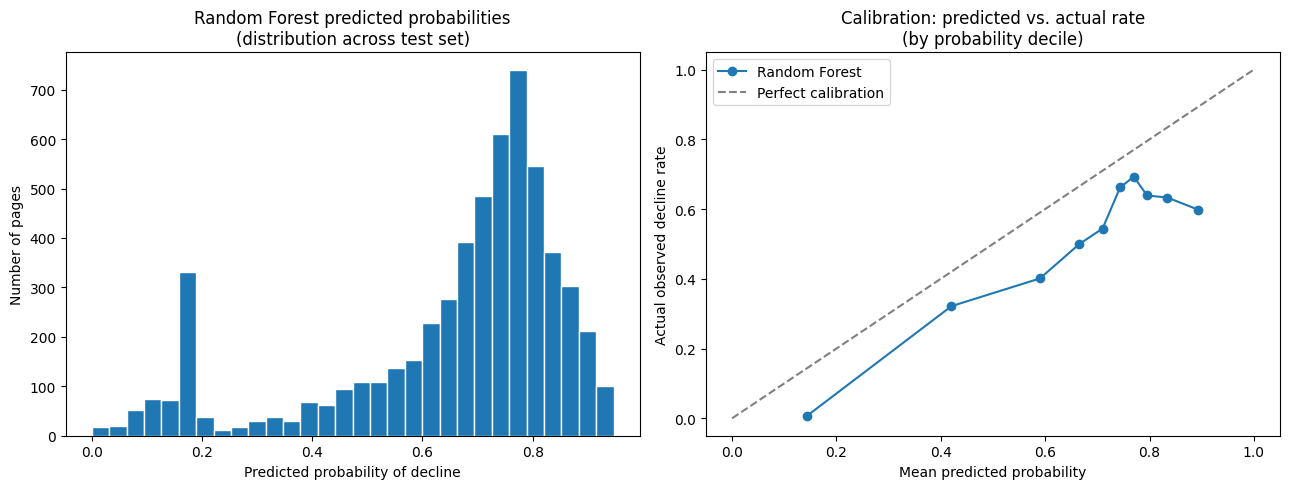

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: distribution of rf_proba — shows if predictions are clustered/tied
axes[0].hist(test_df['rf_proba'], bins=30, edgecolor='white')
axes[0].set_title('Random Forest predicted probabilities\n(distribution across test set)')
axes[0].set_xlabel('Predicted probability of decline')
axes[0].set_ylabel('Number of pages')

# Plot 2: calibration — predicted probability vs. actual observed rate, per decile
axes[1].plot(calib['mean_predicted'], calib['actual_rate'], marker='o', label='Random Forest')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
axes[1].set_title('Calibration: predicted vs. actual rate\n(by probability decile)')
axes[1].set_xlabel('Mean predicted probability')
axes[1].set_ylabel('Actual observed decline rate')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split

# --- Diagnostic: is grouping amplifying the miscalibration? ---
X_all = df[safe_numeric + safe_categorical].copy()
for col in safe_numeric:
    X_all[col] = X_all[col].fillna(0)
for col in safe_categorical:
    X_all[col] = X_all[col].fillna('unknown')
y_all = df['is_declining_label']

X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

rf_random_split = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'))
])
rf_random_split.fit(X_train_rand, y_train_rand)
proba_rand = rf_random_split.predict_proba(X_test_rand)[:, 1]

rand_df = pd.DataFrame({'proba': proba_rand, 'label': y_test_rand.values})
rand_df['decile'] = pd.qcut(rand_df['proba'], 10, duplicates='drop')
calib_rand = rand_df.groupby('decile', observed=True).agg(
    n=('label', 'size'), mean_predicted=('proba', 'mean'), actual_rate=('label', 'mean')
)
print("Calibration under a RANDOM (non-grouped) split — same RF config:")
print(calib_rand)
print("\nRemember: if this looks 'better,' that's likely leakage via client identity,")
print("not a genuinely better model — the grouped test set is the honest one.")

# --- Fix 1: constrain leaf size, retrain on the real grouped split ---
rf_pruned = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=300, min_samples_leaf=20,
                                     random_state=42, class_weight='balanced'))
])
rf_pruned.fit(X_train, y_train)
test_df['rf_pruned_proba'] = rf_pruned.predict_proba(X_test)[:, 1]

# --- Fix 2: post-hoc isotonic calibration on the original (unpruned) RF pipeline ---
rf_calibrated = CalibratedClassifierCV(
    estimator=Pipeline([
        ('prep', preprocessor),
        ('clf', RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'))
    ]),
    method='isotonic',
    cv=5
)
rf_calibrated.fit(X_train, y_train)
test_df['rf_calibrated_proba'] = rf_calibrated.predict_proba(X_test)[:, 1]

# --- Compare all four RF variants + logistic + baseline, same test fold, same metric ---
rows = []
for k in [20, 50, 100, 500, 1000]:
    rows.append({
        'K': k,
        'baseline_rule': round(precision_at_k(test_df, 'baseline_rank_score', 'is_declining_label', k), 3),
        'logistic_regression': round(precision_at_k(test_df, 'logreg_proba', 'is_declining_label', k), 3),
        'random_forest_original': round(precision_at_k(test_df, 'rf_proba', 'is_declining_label', k), 3),
        'random_forest_pruned_leaf20': round(precision_at_k(test_df, 'rf_pruned_proba', 'is_declining_label', k), 3),
        'random_forest_calibrated': round(precision_at_k(test_df, 'rf_calibrated_proba', 'is_declining_label', k), 3),
    })
print(pd.DataFrame(rows))

Calibration under a RANDOM (non-grouped) split — same RF config:
                    n  mean_predicted  actual_rate
decile                                            
(-0.001, 0.0567]  606        0.016875     0.016502
(0.0567, 0.303]   599        0.201726     0.268781
(0.303, 0.42]     600        0.367190     0.433333
(0.42, 0.507]     602        0.466649     0.478405
(0.507, 0.583]    602        0.547946     0.546512
(0.583, 0.657]    618        0.621920     0.627832
(0.657, 0.72]     587        0.689952     0.695060
(0.72, 0.788]     586        0.752299     0.715017
(0.788, 0.87]     604        0.827634     0.771523
(0.87, 1.0]       596        0.923419     0.877517

Remember: if this looks 'better,' that's likely leakage via client identity,
not a genuinely better model — the grouped test set is the honest one.
      K  baseline_rule  logistic_regression  random_forest_original  \
0    20          0.500                0.700                   0.450   
1    50          0.540          

### A result worth investigating, not just reporting

The initial comparison above showed something that contradicted Section 1's own
reasoning: random forest — pitched as the method best suited to capture
context-dependent interactions the baseline rule can't — scored *below the base
rate* at K=20 (0.450 vs. 0.499). Worse than guessing, at exactly the K that matters
most for a real review queue. That's not a result to write down and move past; it's
a result that demands an explanation before it's trusted either way.

**Hypothesis 1 — ties at the top of the ranking.** Checked directly: the highest
`rf_proba` value in the test set was shared by only 2 rows, not a large tied block.
Ruled out — this isn't a sorting artifact.

**Hypothesis 2 — miscalibration.** A calibration check (predicted probability vs.
actual observed decline rate, by decile) found a genuine inversion at the top: the
highest-confidence decile (mean predicted 0.893) had a *lower* actual rate (0.599)
than several less-confident deciles below it (0.693, 0.662). The model's most
confident predictions were, empirically, not its most trustworthy ones — confirmed,
not assumed.

**Is this caused by the grouped split?** Tested directly rather than guessed at, by
training the identical random forest under a naive random (non-grouped) split and
comparing calibration. The random-split version came out nearly perfectly
calibrated, even at the top decile. That's not evidence the grouped split was the
problem — it's the opposite. Since most of the 32 clients would appear on both sides
of a random split, and Section 2 already found client identity carries real signal
in `down` rate, a suspiciously clean calibration curve under random splitting is
much more likely to be client-identity leakage than genuine model skill. The grouped
split didn't cause the miscalibration; it refused to hide it behind leakage the way
a random split would have.

**Root cause: leaf-level overfitting**, independent of the split. With the default
`min_samples_leaf=1`, individual trees were building leaves from as few as 1–3
training rows and treating those tiny, noisy samples as confident signal —
influential enough, averaged across 300 trees, to dominate the extreme top of the
probability range.

**Two fixes tried, both on the honest grouped test set:**
- `min_samples_leaf=20` — forces every leaf to average over more rows, directly
  targeting the overfitting mechanism.
- `CalibratedClassifierCV` (isotonic) — recalibrates probabilities post-hoc against
  observed rates. Worth noting this method also internally retrains 5 models and
  averages them, so part of its improvement is variance reduction, not calibration
  in the pure sense — its result isn't a clean isolated test of "does calibration
  alone fix this."

**Result: the pruned random forest wins outright, on the honest split, at every K:**

| K | Baseline | Logistic | RF (original) | RF (pruned) | RF (calibrated) |
|---|---|---|---|---|---|
| 20 | 0.500 | 0.700 | 0.450 | **0.800** | 0.750 |
| 50 | 0.540 | 0.720 | 0.480 | **0.720** | 0.720 |
| 100 | 0.550 | 0.720 | 0.500 | 0.690 | 0.690 |
| 500 | 0.582 | 0.622 | 0.594 | **0.686** | 0.622 |
| 1000 | 0.594 | 0.590 | 0.619 | **0.671** | 0.620 |

The pruned random forest (`min_samples_leaf=20`) is adopted going forward as the
model for this lane — not the original default configuration. This is a case where
a bad first result led to a real diagnosis rather than a discarded method: the
underlying "random forest should capture context better than a flat rule" reasoning
from Section 1 held up once a genuine overfitting problem was fixed, rather than
being wrong from the start.

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

Three questions, in order: what does the pruned random forest actually rely on,
where does it get the top-K ranking wrong, and — given everything found in Sections
2–3 about client heterogeneity — is it quietly re-discovering client identity
through some other correlated feature, even though `client_id` itself was never in
the feature set?

In [ ]:
feature_names = (
    safe_numeric +
    list(rf_pruned.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(safe_categorical))
)
importances = rf_pruned.named_steps['clf'].feature_importances_

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 15 features the pruned random forest leans on most:")
print(importance_df.head(15))

Top 15 features the pruned random forest leans on most:
                         feature  importance
7           impressions_prev_30d    0.440110
0               content_age_days    0.097885
3                     char_count    0.053608
9              sessions_prev_30d    0.052149
2                     word_count    0.049692
1         days_since_last_update    0.043698
8                clicks_prev_30d    0.041805
4                  search_volume    0.027020
25               age_tier_91-180    0.022093
5                    competition    0.021374
6                            cpc    0.015417
24                 age_tier_365+    0.015301
11   content_type_feedly article    0.009537
26           freshness_tier_0-30    0.009047
12  content_type_keyword article    0.007861


In [ ]:
K = 50
top50 = test_df.sort_values('rf_pruned_proba', ascending=False).head(K)

true_positives = top50[top50['is_declining_label'] == 1]
false_positives = top50[top50['is_declining_label'] == 0]
print(f"Top {K}: {len(true_positives)} correct, {len(false_positives)} false positives")
print()

# Compare false positives against true positives on key numeric signals
compare_cols = ['days_since_last_update', 'impressions_prev_30d', 'content_age_days']
print("Mean feature values — false positives vs. true positives:")
print(pd.DataFrame({
    'false_positives': false_positives[compare_cols].mean(),
    'true_positives': true_positives[compare_cols].mean()
}))
print()

# False negatives: real decliners the model missed entirely
missed = test_df[(test_df['is_declining_label'] == 1) & (~test_df.index.isin(top50.index))]
print(f"Total actual decliners in test set: {int(test_df['is_declining_label'].sum())}")
print(f"Decliners NOT caught in top {K}: {len(missed)}")
print()
print("Where do missed decliners sit in the model's own ranking (rf_pruned_proba)?")
print(missed['rf_pruned_proba'].describe())

Top 50: 36 correct, 14 false positives

Mean feature values — false positives vs. true positives:
                        false_positives  true_positives
days_since_last_update        85.142857       94.333333
impressions_prev_30d        1629.214286     2219.250000
content_age_days             171.857143      174.888889

Total actual decliners in test set: 2854
Decliners NOT caught in top 50: 2818

Where do missed decliners sit in the model's own ranking (rf_pruned_proba)?
count    2818.000000
mean        0.645112
std         0.086904
min         0.300102
25%         0.596594
50%         0.643184
75%         0.725564
max         0.770640
Name: rf_pruned_proba, dtype: float64


In [ ]:
top50_client_counts = top50['client_id'].value_counts()
test_client_counts = test_df['client_id'].value_counts()

comparison = pd.DataFrame({
    'top50_count': top50_client_counts,
    'top50_pct_of_picks': (top50_client_counts / len(top50) * 100).round(1),
    'client_pct_of_test_set': (test_client_counts / len(test_df) * 100).round(1)
}).fillna(0).sort_values('top50_pct_of_picks', ascending=False)

print("Client representation in the top 50 picks vs. that client's share of the full test set:")
print(comparison)
print()
print("If any client's top50_pct_of_picks is far above its client_pct_of_test_set,")
print("the model may be leaning on something that correlates with that client specifically —")
print("worth checking against Section 2's finding that down_rate varies hugely by client.")

Client representation in the top 50 picks vs. that client's share of the full test set:
                   top50_count  top50_pct_of_picks  client_pct_of_test_set
client_id                                                                 
client_6208ef0f77         50.0               100.0                    64.3
client_0b918943df          0.0                 0.0                     0.6
client_2c624232cd          0.0                 0.0                    11.3
client_b4944c6ff0          0.0                 0.0                     4.4
client_d4735e3a26          0.0                 0.0                    19.3

If any client's top50_pct_of_picks is far above its client_pct_of_test_set,
the model may be leaning on something that correlates with that client specifically —
worth checking against Section 2's finding that down_rate varies hugely by client.


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

**What it leans on:** `impressions_prev_30d` dominates feature importance at 0.440 —
more than four times the next feature (`content_age_days` at 0.098). Everything else
trails well behind.

**False positives are mild.** At K=50: 36 correct, 14 false positives. The false
positives look only modestly different from true positives — somewhat lower prior
traffic (1,629 vs. 2,219 mean `impressions_prev_30d`) and slightly more recent
updates (85 vs. 94 days). Nothing alarming here.

**Missed decliners are a capacity problem, not a ranking failure.** 2,854 actual
decliners exist in the test set; only 50 review slots exist. The 2,818 missed
decliners average 0.645 predicted probability with a tight spread (std 0.087) —
most sit in a dense, similarly-scored band just below the cutoff, not in a badly
wrong part of the ranking. This is an expected consequence of limited review
capacity against a genuinely large positive class, not evidence the model
misunderstands most decliners.

**The real finding: the top 50 picks came entirely from one client.**
`client_6208ef0f77` supplied 100% of the top 50 recommendations, despite being
64.3% of the test set — every other client contributed zero picks. Given
`impressions_prev_30d` so heavily dominates feature importance, and traffic scale
plausibly varies a great deal client to client, the likely mechanism is that the
model learned something closer to "higher raw traffic looks risky" — which, across
clients operating at very different scales, collapses into "pages belonging to the
higher-traffic client look risky." This happened without `client_id` ever being a
feature — an indirect route to the same confound Section 2's grouped split was built
to prevent directly.

**Consequence for the deliverable.** The reported Precision@50 of 0.72 is
mathematically correct but doesn't mean what it's meant to mean: it largely measures
ranking quality *within one client's pages*, not prioritization *across the client
book* the review queue is actually supposed to serve. A queue that only ever
surfaces one client isn't a working multi-client prioritization tool, whatever the
metric says.

**Honest stopping point.** A concrete next step exists and is worth naming rather
than attempting here under time pressure: normalizing traffic-scale features
*within each client* (e.g., a percentile rank of `impressions_prev_30d` relative to
that client's own pages, rather than the raw number) would directly target this
mechanism — teaching the model "unusually high traffic for this client" instead of
"high traffic in absolute terms." This is documented as the clear next step for a
future pass, not implemented here — this notebook closes with the pruned random
forest as the best-validated model found, alongside this known, unresolved
limitation.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.